# Importing Database

In [1]:
# pip install kagglehub (Successfully installed kagglehub-0.3.13)
#!pip install --upgrade kagglehub

import kagglehub

In [2]:
path = kagglehub.dataset_download("mdrazakhan/linear-regression-dataset")

In [3]:
print("Path to dataset files:", path)

Path to dataset files: C:\Users\prati\.cache\kagglehub\datasets\mdrazakhan\linear-regression-dataset\versions\2


# Loading Dataset

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(r"C:\Users\prati\.cache\kagglehub\datasets\mdrazakhan\linear-regression-dataset\versions\2\cars.csv")

In [6]:
df.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


## Inspecting dataset

In [7]:
df

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105
5,VW,Up!,1000,929,105
6,Skoda,Fabia,1400,1109,90
7,Mercedes,A-Class,1500,1365,92
8,Ford,Fiesta,1500,1112,98
9,Audi,A1,1600,1150,99


In [8]:
df.info() # checking for null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     36 non-null     object
 1   Model   36 non-null     object
 2   Volume  36 non-null     int64 
 3   Weight  36 non-null     int64 
 4   CO2     36 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.5+ KB


# Defining variables

In [9]:
# Features (independent variables)
X = df[['Volume', 'Weight']]

# Target (dependent variable)
Y = df['CO2']

### Rule of Thumb
#### If you start with lists → use NumPy to reshape.

#### If you start with a DataFrame → no NumPy needed.

In [12]:
from sklearn.model_selection import train_test_split # train_test_split randomly spilts data

In [13]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.3, random_state=42) #test_size is use to slipt data size use for testing

In [14]:
X_test

,Volume,Weight
35,2500,1395
13,1600,1252
26,2000,1490
30,2100,1605
16,1600,1365
31,2000,1746
21,2000,1428
12,1000,1112
8,1500,1112
17,2200,1280


In [15]:
Y_train

34    109
0      99
4     105
29    114
15     97
19    105
5     105
11    101
1      95
24     99
2      95
33    108
3      90
32    104
23     99
27    114
10     99
22     99
18    104
25    102
6      90
20     94
7      92
14     97
28    109
Name: CO2, dtype: int64

In [16]:
X_train

,Volume,Weight
34,1600,1405
0,1000,790
4,1500,1140
29,2000,1705
15,1600,1330
19,2000,1328
5,1000,929
11,1300,990
1,1200,1160
24,2000,1415


In [17]:
Y_test

35    120
13     94
26    104
30    115
16     99
31    117
21     99
12     99
8      98
17    104
9      99
Name: CO2, dtype: int64

# LinearRegression

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
lr=LinearRegression()

In [20]:
lr.fit(X_train, Y_train)

LinearRegression()

In [21]:
lr.intercept_ 

84.58784534640245

In [22]:
lr.coef_

array([0.00482015, 0.00720613])

In [23]:
Y_pred=lr.predict(X_test)

In [24]:
Y_pred

array([106.69078079, 101.32216645, 104.96528686, 106.27600726,
       102.1364593 , 106.81005652, 104.51850671,  97.42121635,
        99.83129276, 104.41602982, 100.58714104])

# Evaluation

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
r2_score (Y_test,Y_pred)# r2 score closer to 1 mean model is good

0.41008714763391063

In [27]:
mean_squared_error(Y_test,Y_pred)

41.85943595384499

In [28]:
mean_absolute_error(Y_test,Y_pred)

4.961711094071864

# Visualization

In [29]:
import matplotlib.pyplot as plt

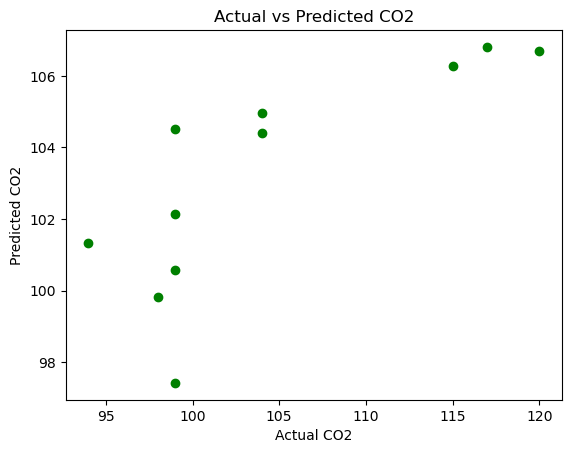

In [32]:
plt.scatter(Y_test, Y_pred, color='green')
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2")
plt.show()

###### The linear regression model achieved an R² score of ~0.41, indicating moderate predictive performance.

# Polynomial regression

In [33]:
from sklearn.preprocessing import PolynomialFeatures

In [34]:
poly2 = PolynomialFeatures(degree=2)

In [35]:
poly2.fit(X_train)

PolynomialFeatures()

In [36]:
X_poly2_train = poly2.transform(X_train)

In [37]:
X_poly2_test = poly2.transform(X_test)

In [38]:
lr.fit(X_poly2_train, Y_train)

LinearRegression()

In [39]:
lr.intercept_

128.07838070360998

In [40]:
lr.coef_

array([ 0.00000000e+00,  3.73893568e-02, -1.03852970e-01, -3.97914441e-05,
        7.83355987e-05, -7.26518911e-06])

In [41]:
Y_pred=lr.predict(X_poly2_test)

In [42]:
X_poly2=poly2.fit_transform(X)

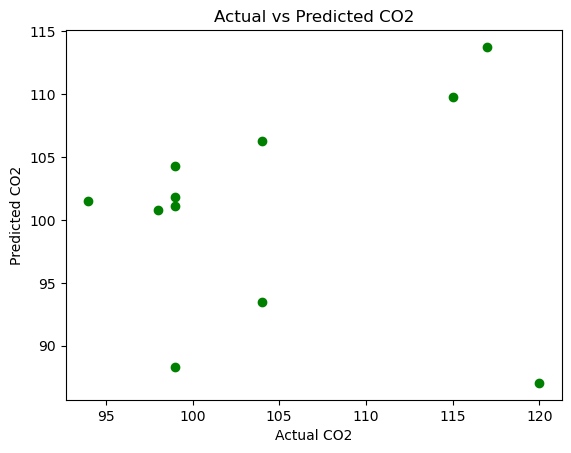

In [49]:
plt.scatter(Y_test, Y_pred, color='green')
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2")
plt.show()

In [46]:
r2_score(Y_test, Y_pred)

-0.8699443997610494

#### A polynomial regression model (degree 2) was also tested to capture potential non-linear relationships. However, it resulted in a significantly worse R² score (~ -0.87), indicating overfitting and poor generalization.

#### Therefore, linear regression is more appropriate for this dataset.